# Pakistani Politician Image Classifier – Complete Training Pipeline

An end-to-end facial recognition pipeline that classifies 16 Pakistani politicians
from face images using deep metric learning (ArcFace) and standard transfer learning.

All pipeline logic—data preparation, model definitions, training loops, and
evaluation—resides in the `training/` Python package. This notebook is a **thin
orchestration wrapper** that installs dependencies, imports the package, and
delegates execution to `main()`. The package can also be run standalone

```bash
python training/main.py
```


## Setup and Dependencies

The cells below install packages absent from the default Kaggle runtime:

- **`facenet-pytorch`** – provides the MTCNN face detector and the
  InceptionResNetV1 backbone pre-trained on VGGFace2 and CASIA-WebFace.
- **`imagehash`** – used for perceptual-hash (pHash) near-duplicate detection.

The remaining required packages (`timm`, `albumentations`) are installed
automatically by `main()` at runtime.

###### from IPython.core.display import HTML
#HTML("<script>Jupyter.notebook.kernel.restart()</script>")


## Modular Pipeline Wrapper

The cell below is the **sole execution entry point**. It:

1. Injects the correct directory into `sys.path` so that `import training`
   resolves on both Kaggle (package mounted as a dataset input or present in
   `/kaggle/working`) and local environments.
2. Imports `config` to confirm the package is reachable.
3. Calls `main()`, which executes the complete eight-stage pipeline
   (see *Pipeline Stages* below for details).

All outputs are written to `/kaggle/working/` (Kaggle) or
`project_outputs/` (local).

In [1]:
# ============================================================
# VERIFIED KAGGLE VENV + TRAINING PIPELINE (FIXED BACKEND)
# ============================================================

import os, sys, subprocess, shutil

VENV = "/kaggle/working/venv"
PIP = f"{VENV}/bin/pip"
PYTHON = f"{VENV}/bin/python"

# ---------- 1. Clean old venv and create with virtualenv ----------
if os.path.exists(VENV):
    shutil.rmtree(VENV)

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "virtualenv"], check=True)
subprocess.run([sys.executable, "-m", "virtualenv", VENV], check=True)

# ---------- 2. Upgrade pip tools inside venv ----------
subprocess.run([PIP, "install", "-q", "--upgrade", "pip", "setuptools", "wheel"], check=True)

# ---------- 3. Install NumPy first ----------
subprocess.run([PIP, "install", "-q", "numpy==1.26.4"], check=True)

# ---------- 4. Torch + TorchVision ----------
subprocess.run([PIP, "install", "-q",
    "torch==2.2.2", "torchvision==0.17.2",
    "--index-url", "https://download.pytorch.org/whl/cu121"
], check=True)

# ---------- 5. All other packages (exact proven versions) ----------
packages = [
    "facenet-pytorch==2.6.0",
    "opencv-python-headless==4.9.0.80",
    "albumentations==1.4.0",          # prevents numpy upgrade
    "imagehash",
    "timm",
    "scikit-learn",
    "scipy",
    "matplotlib",
    "seaborn",
    "pandas",
    "Pillow==10.2.0",
    "tqdm",
    "requests",
    "wrapt",                           # stop the recurring 'ModuleNotFoundError: wrapt'
]

for pkg in packages:
    subprocess.run([PIP, "install", "-q", pkg], check=True)

# ---------- 6. Force NumPy back to 1.26.4 (just in case) ----------
subprocess.run([PIP, "install", "-q", "--force-reinstall", "numpy==1.26.4"], check=True)

# ---------- 7. Write runner script ----------
runner_code = r'''
import os, sys, shutil
import numpy as np
from PIL import Image
import torch

print("=" * 60)
print(" STARTING TRAINING PIPELINE")
print("=" * 60)

# Copy training package
target = "/kaggle/working/training"
if os.path.exists(target):
    shutil.rmtree(target)

inner_src = None
for root, dirs, files in os.walk("/kaggle/input"):
    if os.path.basename(root) == "training":
        if os.path.isfile(os.path.join(root, "main.py")):
            inner_src = root
            break
if inner_src is None:
    raise RuntimeError(" training/main.py not found")
shutil.copytree(inner_src, target)
sys.path.insert(0, "/kaggle/working")

# float(angle) fix
file_path = "/kaggle/working/training/data_prep.py"
if os.path.exists(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()
    with open(file_path, "w") as f:
        for line in lines:
            if "img.rotate(-angle" in line and "float(angle)" not in line:
                line = line.replace("-angle", "-float(angle)")
            f.write(line)
    print(" float(angle) patch applied")

# MTCNN PIL patch
from facenet_pytorch.models.mtcnn import MTCNN as MTCNNClass
original_detect = MTCNNClass.detect
def patched_detect(self, img, landmarks=False):
    if isinstance(img, Image.Image):
        img = np.array(img.convert("RGB"), dtype=np.uint8)
    return original_detect(self, img, landmarks=landmarks)
MTCNNClass.detect = patched_detect
print(" MTCNN patch applied")

sys.setrecursionlimit(10000)

print(f" CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f" GPU: {torch.cuda.get_device_name(0)}")

from training.config import config
print(f" Models configured: {len(config.MODELS_TO_TRAIN)}")
from training.main import main
main()
'''

runner_script = "/kaggle/working/run_pipeline.py"
with open(runner_script, "w") as f:
    f.write(runner_code)

# ---------- 8. Run pipeline inside venv (UNSET MPLBACKEND to avoid matplotlib error) ----------
print("\n Starting training...\n")
env = os.environ.copy()
env.pop('MPLBACKEND', None)          # <-- this is the critical fix

result = subprocess.run([PYTHON, runner_script], env=env, check=False)

if result.returncode == 0:
    print("\n TRAINING COMPLETED SUCCESSFULLY")
else:
    print(f"\n TRAINING FAILED WITH EXIT CODE {result.returncode}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 30.1 MB/s eta 0:00:00
created virtual environment CPython3.12.12.final.0-64-x86_64 in 386ms
  creator CPython3Posix(dest=/kaggle/working/venv, clear=False, no_vcs_ignore=False, global=False)
  seeder FromAppData(download=False, pip=bundle, via=copy, app_data_dir=/root/.cache/virtualenv)
    added seed packages: pip==26.1.1
  activators BashActivator,CShellActivator,FishActivator,NushellActivator,PowerShellActivator,PythonActivator,XonshActivator


Error in sitecustomize; set PYTHONVERBOSE for traceback:
ModuleNotFoundError: No module named 'wrapt'
Error in sitecustomize; set PYTHONVERBOSE for traceback:
ModuleNotFoundError: No module named 'wrapt'
Error in sitecustomize; set PYTHONVERBOSE for traceback:
ModuleNotFoundError: No module named 'wrapt'
Error in sitecustomize; set PYTHONVERBOSE for traceback:
ModuleNotFoundError: No module named 'wrapt'
Error in sitecustomize; set PYTHONVERBOSE for traceback:
ModuleNotFoundError: No module named 'wrapt'
Error in sitecustomize; set PYTHONVERBOSE for traceback:
ModuleNotFoundError: No module named 'wrapt'
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
facenet-pytorch 2.6.0 requires numpy<2.0.0,>=1.24.0, but you have numpy 2.4.4 which is incompatible.
Error in sitecustomize; set PYTHONVERBOSE for traceback:
ModuleNotFoundError: No module named 'wrapt'
Error in s


 Starting training...

 STARTING TRAINING PIPELINE
 float(angle) patch applied
 MTCNN patch applied
 CUDA Available: True
 GPU: Tesla T4
 Models configured: 3

STARTING TRAINING PIPELINE
Installing facenet-pytorch...

Using device: cuda
   GPU: Tesla T4
   Memory: 15.64 GB

PHASE 1: LOADING DATA

Running on Kaggle – searching for datasets...
   Found raw images: /kaggle/input/datasets/omerfarooqq/politician-data/data/raw
     barrister_gohar: 100 images
     asif_ali_zardari: 101 images
     imran_khan: 97 images
     ahsan_iqbal: 100 images
     shehryar_afridi: 88 images
     nawaz_sharif: 92 images
     asfandyar_wali: 89 images
     maryam_nawaz: 108 images
     altaf_hussain: 102 images
     bilawal_bhutto: 107 images
     fazlur_rehman: 101 images
     pervez_musharraf: 86 images
     ahmed_sharif_chaudhry: 92 images
     khawaja_asif: 101 images
     chaudhry_shujaat: 93 images
     shahbaz_sharif: 126 images
   Found raw 2 images: /kaggle/input/datasets/omerfarooqq/politician-

  Processing:   0%|          | 0/216 [00:00<?, ?it/s]

  LOW Kept: 106 | Removed: 113

Aligning: asfandyar_wali


...

Epoch 29/30 - Train Loss: 0.9827, Train Acc: 82.38% | Val Loss: 0.9574, Val Acc: 90.15%


Epoch 30 [Val]: 100%|██████████| 13/13 [00:01<00:00,  6.70it/s, loss=0.9588, acc=89.66%]


Epoch 30/30 - Train Loss: 0.9643, Train Acc: 74.86% | Val Loss: 0.9588, Val Acc: 89.66%

Early stopping at epoch 30

EVALUATING: RESNET50


Testing: 100%|██████████| 9/9 [00:14<00:00,  1.59s/it]



Test Accuracy: 94.85%

                       precision    recall  f1-score   support

ahmed_sharif_chaudhry     1.0000    1.0000    1.0000         7
          ahsan_iqbal     1.0000    1.0000    1.0000         9
        altaf_hussain     0.9000    0.8182    0.8571        11
       asfandyar_wali     1.0000    1.0000    1.0000         4
     asif_ali_zardari     1.0000    1.0000    1.0000         8
      barrister_gohar     1.0000    1.0000    1.0000         4
       bilawal_bhutto     0.8750    0.8750    0.8750         8
     chaudhry_shujaat     1.0000    1.0000    1.0000         5
        fazlur_rehman     1.0000    1.0000    1.0000         6
           imran_khan     0.8636    1.0000    0.9268        19
         khawaja_asif     1.0000    1.0000    1.0000        10
         maryam_nawaz     1.0000    1.0000    1.0000         9
         nawaz_sharif     1.0000    0.8182    0.9000        11
     pervez_musharraf     1.0000    1.0000    1.0000         8
       shahbaz_sharif     1.00

---

## Pipeline Stages

The following sections document each stage executed automatically by `main()`.
No additional code is needed; this section exists for reference and reproducibility.

### Stage 1 – Data Loading

Raw images are copied from the Kaggle input directories into local `data/raw`
and `data/raw2` folders. The helper function `load_kaggle_data()` in
`training/data_prep.py` detects the Kaggle environment via
`KAGGLE_KERNEL_RUN_TYPE` and adjusts source paths accordingly.

### Stage 2 – Data Merging

Both raw image sources are merged into a single `data/raw_merged/` directory
using `merge_raw_folders()`. Images from the second source are renamed
sequentially (continuing from the last index in the first source) to avoid
filename collisions across the two datasets.

### Stage 3 – Face Alignment and Deduplication

**MTCNN alignment** (`align_faces_mtcnn()`):
- Detects faces using the MTCNN three-stage cascade detector.
- Discards images where zero or more than one face is detected.
- Aligns the detected face using five facial landmarks.
- Crops and resizes to **336 × 336 px** with a 0.2 margin ratio.
- Minimum image resolution gate: 60 × 60 px before alignment.

**pHash deduplication** (`deduplicate_phash()`):
- Computes a 64-bit perceptual hash for each aligned image.
- Removes near-duplicate pairs with a hash distance ≤ 5 to prevent
  data leakage across train/val/test splits.

### Stage 4 – Dataset Splitting

`split_dataset()` applies a stratified split over the aligned images:

| Split | Fraction |
|---|---|
| Train | 75 % |
| Validation | 15 % |
| Test | 10 % |

Classes with fewer than `MIN_IMAGES_FOR_SPLIT` (default: 5) images are
excluded. The directory structure written is `dataset/{train,val,test}/<class>/`.

### Stage 5 – Offline Data Augmentation

`run_offline_augmentation()` targets under-represented training classes.
For each class with fewer than 120 training images, it generates
**3 augmented copies** of every original image using an Albumentations
pipeline that includes:

- Geometric transforms: ShiftScaleRotate, HorizontalFlip, Perspective
- Colour jitter: RandomBrightnessContrast, HueSaturationValue, CLAHE
- Blur / noise: GaussianBlur, GaussNoise, ImageCompression

Online augmentation (random crops, flips, colour jitter) is additionally
applied to the training DataLoader at runtime.

### Stage 6 – Model Architecture

Three backbone families are supported:

**InceptionResNetV1 (ArcFace path)**
- Pre-trained weights: VGGFace2 or CASIA-WebFace (via `facenet-pytorch`).
- Wrapped by `FaceEmbeddingModel` which exposes a 512-dimensional embedding
  head and an optional classification head.
- Trained with ArcFace metric loss (see next section).

**EfficientNet-B3 (ArcFace path)**
- Loaded via `timm`; embedding size 512.
- Wrapped by `EfficientNetEmbeddingModel`.

**ResNet-50 / ResNet-152 / VGG-16 / ConvNeXt (CE path)**
- Loaded from `torchvision.models` or `timm` with ImageNet weights.
- Final fully-connected layer replaced with a 16-class head.
- Trained with cross-entropy loss and optional class weights.

### Loss Function – ArcFace

`ArcMarginProduct` adds an angular margin *m* = 0.3 to the ground-truth
class angle before applying the scale factor *s* = 64.0:

```
logit_i = s * cos(theta_i + m)   for the target class
logit_j = s * cos(theta_j)       for all other classes
```

The final loss is `F.cross_entropy(logits, labels, label_smoothing=0.1)`.
During validation and inference the margin is **not** applied—raw cosine
similarity logits are used instead, which avoids inflating validation loss.

### Training Strategy

| Setting | Value |
|---|---|
| Optimiser | AdamW |
| LR schedule | Cosine annealing |
| Head LR | 1 × 10⁻⁴ |
| Backbone unfreeze LR | 3 × 10⁻⁶ |
| Weight decay | 1 × 10⁻⁴ |
| Gradient clipping | max-norm = 1.0 |
| Mixed precision | `torch.cuda.amp` |
| MixUp | α = 0.2, probability = 0.5 |
| Early stopping | patience = 10 epochs |
| Epochs | 30 |

**Backbone freezing strategy:** layers are frozen for epochs 1–5. At epoch 6
the optimiser is rebuilt with discriminative learning rates: the classification
head uses LR = 1 × 10⁻⁴ while the backbone (ResNet layer4 / ArcFace backbone)
uses LR = 1 × 10⁻⁵ or 3 × 10⁻⁶.

### Evaluation and Metrics

`evaluate_model()` runs on the held-out test set after each model is trained:

- **Test-Time Augmentation (TTA):** 5-crop + horizontal flip (10 views per
  image); logits are averaged before taking the argmax.
- **Metrics:** overall accuracy, macro-averaged precision, recall, F1
  (via `sklearn.metrics`).
- **Confusion matrix:** saved as a seaborn heatmap to
  `{OUTPUT_DIR}/plots/{model}_confusion_matrix.png`.
- **Top-5 misclassified samples:** displayed inline with true and predicted labels.
- **Optional mislabeled audit** (`config.FLAG_MISLABELED = True`): scans the
  training set and flags images the model predicts with > 80 % confidence as a
  different class than their folder label.

### Training Loop Details

- **ArcFace validation:** cosine similarity logits (no margin) are used for
  validation accuracy, preventing artificially low validation scores.
- **Optimizer rebuild at epoch 6:** ArcFace class-weight parameters are
  explicitly included in the new optimizer parameter groups to prevent them
  being silently dropped during the backbone-unfreeze step.
- **Device consistency fix:** `class_weights` tensors are moved to the same
  device as the model before `nn.CrossEntropyLoss` is instantiated, resolving
  a runtime error present in the original monolithic notebook.
- **Best checkpoint:** the model state achieving the highest validation
  accuracy is restored at the end of training via `deepcopy`.

---

## Results and Export

After training completes, all outputs are available in `/kaggle/working/`:

| Directory | Contents |
|---|---|
| `models/` | Best model checkpoints (`{model}_best.pth`) |
| `plots/` | Training curves and confusion matrix heatmaps (PNG) |
| `results/` | `model_comparison.csv` with accuracy, precision, recall, F1 |

The two cells below create downloadable zip archives of these outputs directly
from the Kaggle notebook interface.

In [2]:
import shutil
import os

base_dir = "/kaggle/working"
zip_path = "/kaggle/working/project_outputs"

folders_to_zip = ["models", "plots", "results"]

# Create a temp directory to gather selected folders
temp_dir = "/kaggle/working/_temp_zip"
os.makedirs(temp_dir, exist_ok=True)

# Copy selected folders into temp dir
for folder in folders_to_zip:
    src = os.path.join(base_dir, folder)
    dst = os.path.join(temp_dir, folder)
    
    if os.path.exists(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f"✓ Added: {folder}")
    else:
        print(f"Skipped (not found): {folder}")

# Create zip
shutil.make_archive(zip_path, 'zip', temp_dir)

print(f"\nZip created: {zip_path}.zip")

# Optional: remove temp folder
shutil.rmtree(temp_dir)

✓ Added: models
✓ Added: plots
✓ Added: results

Zip created: /kaggle/working/project_outputs.zip


In [3]:
import shutil, os
from IPython.display import FileLink

raw_merged_dir = "data/raw_merged"
zip_base = "/kaggle/working/raw_merged"          # without .zip extension
zip_path = zip_base + ".zip"

if os.path.isdir(raw_merged_dir):
    # Create the zip archive
    shutil.make_archive(zip_base, 'zip', raw_merged_dir)
    print(f"✔ Archive created: {zip_path}")
    
    # Show a clickable download link
    display(FileLink(zip_path))
else:
    print(" 'data/raw_merged' not found. Run the merge cell first.")

✔ Archive created: /kaggle/working/raw_merged.zip


/kaggle/working/raw_merged.zip

## InceptionResNetV1 (VGGFace2)

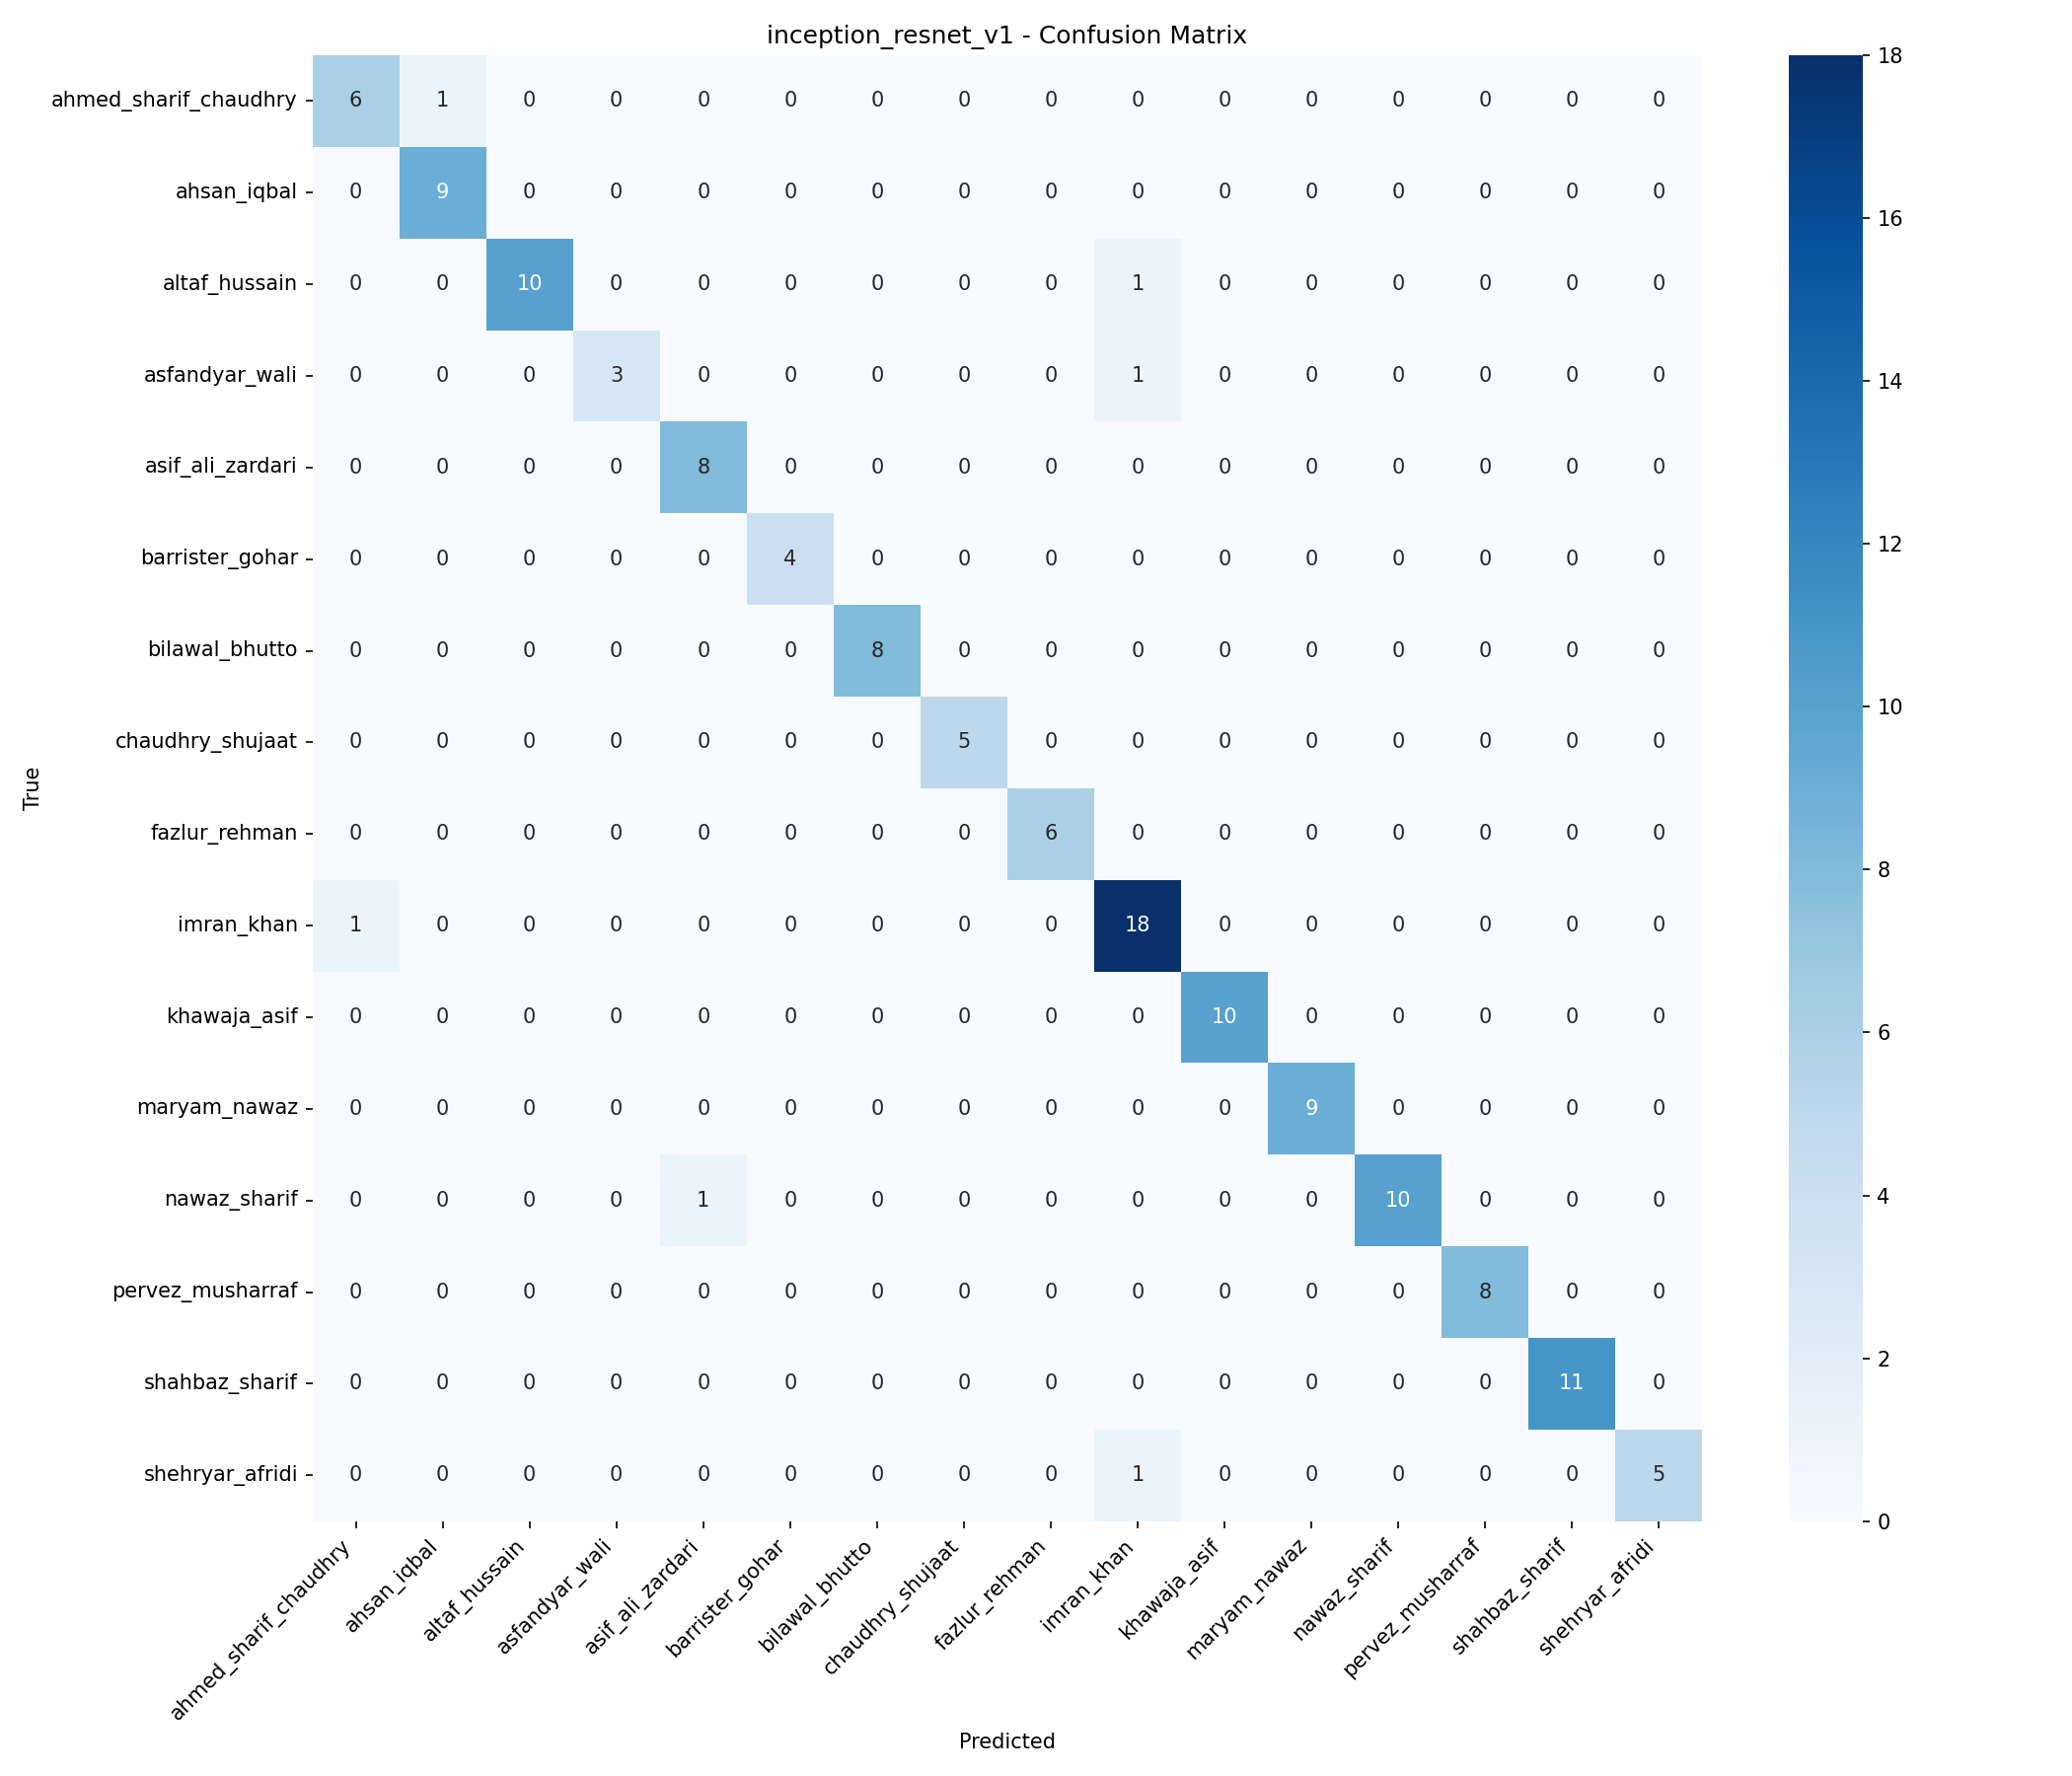

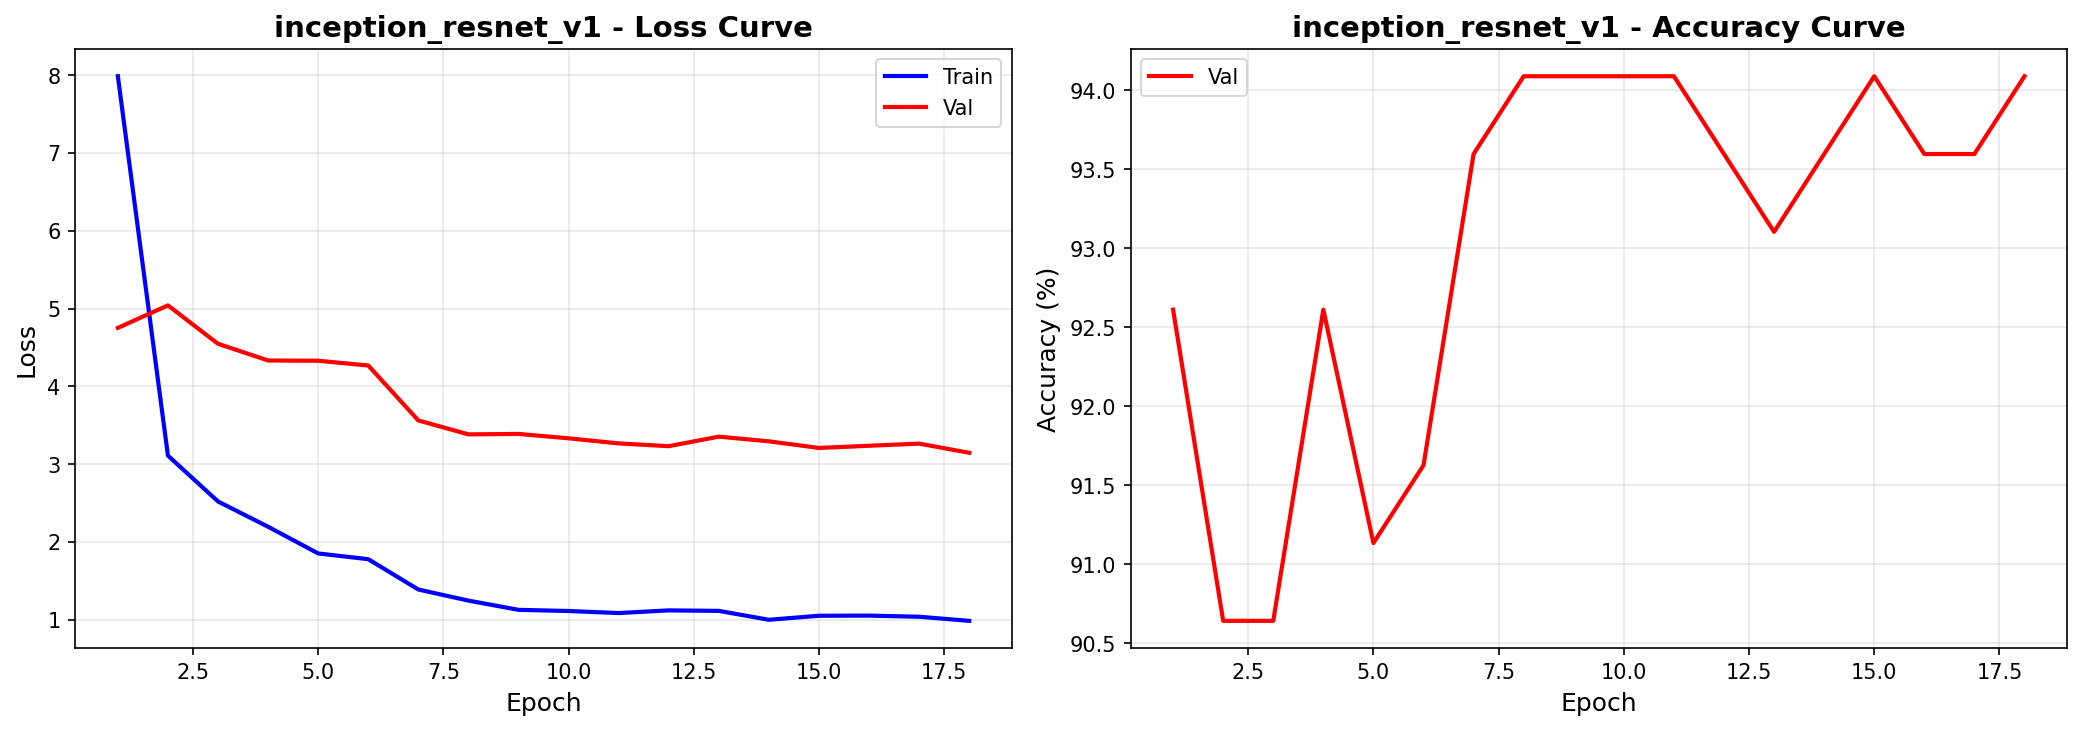

## InceptionResNetV1 (CASIA)

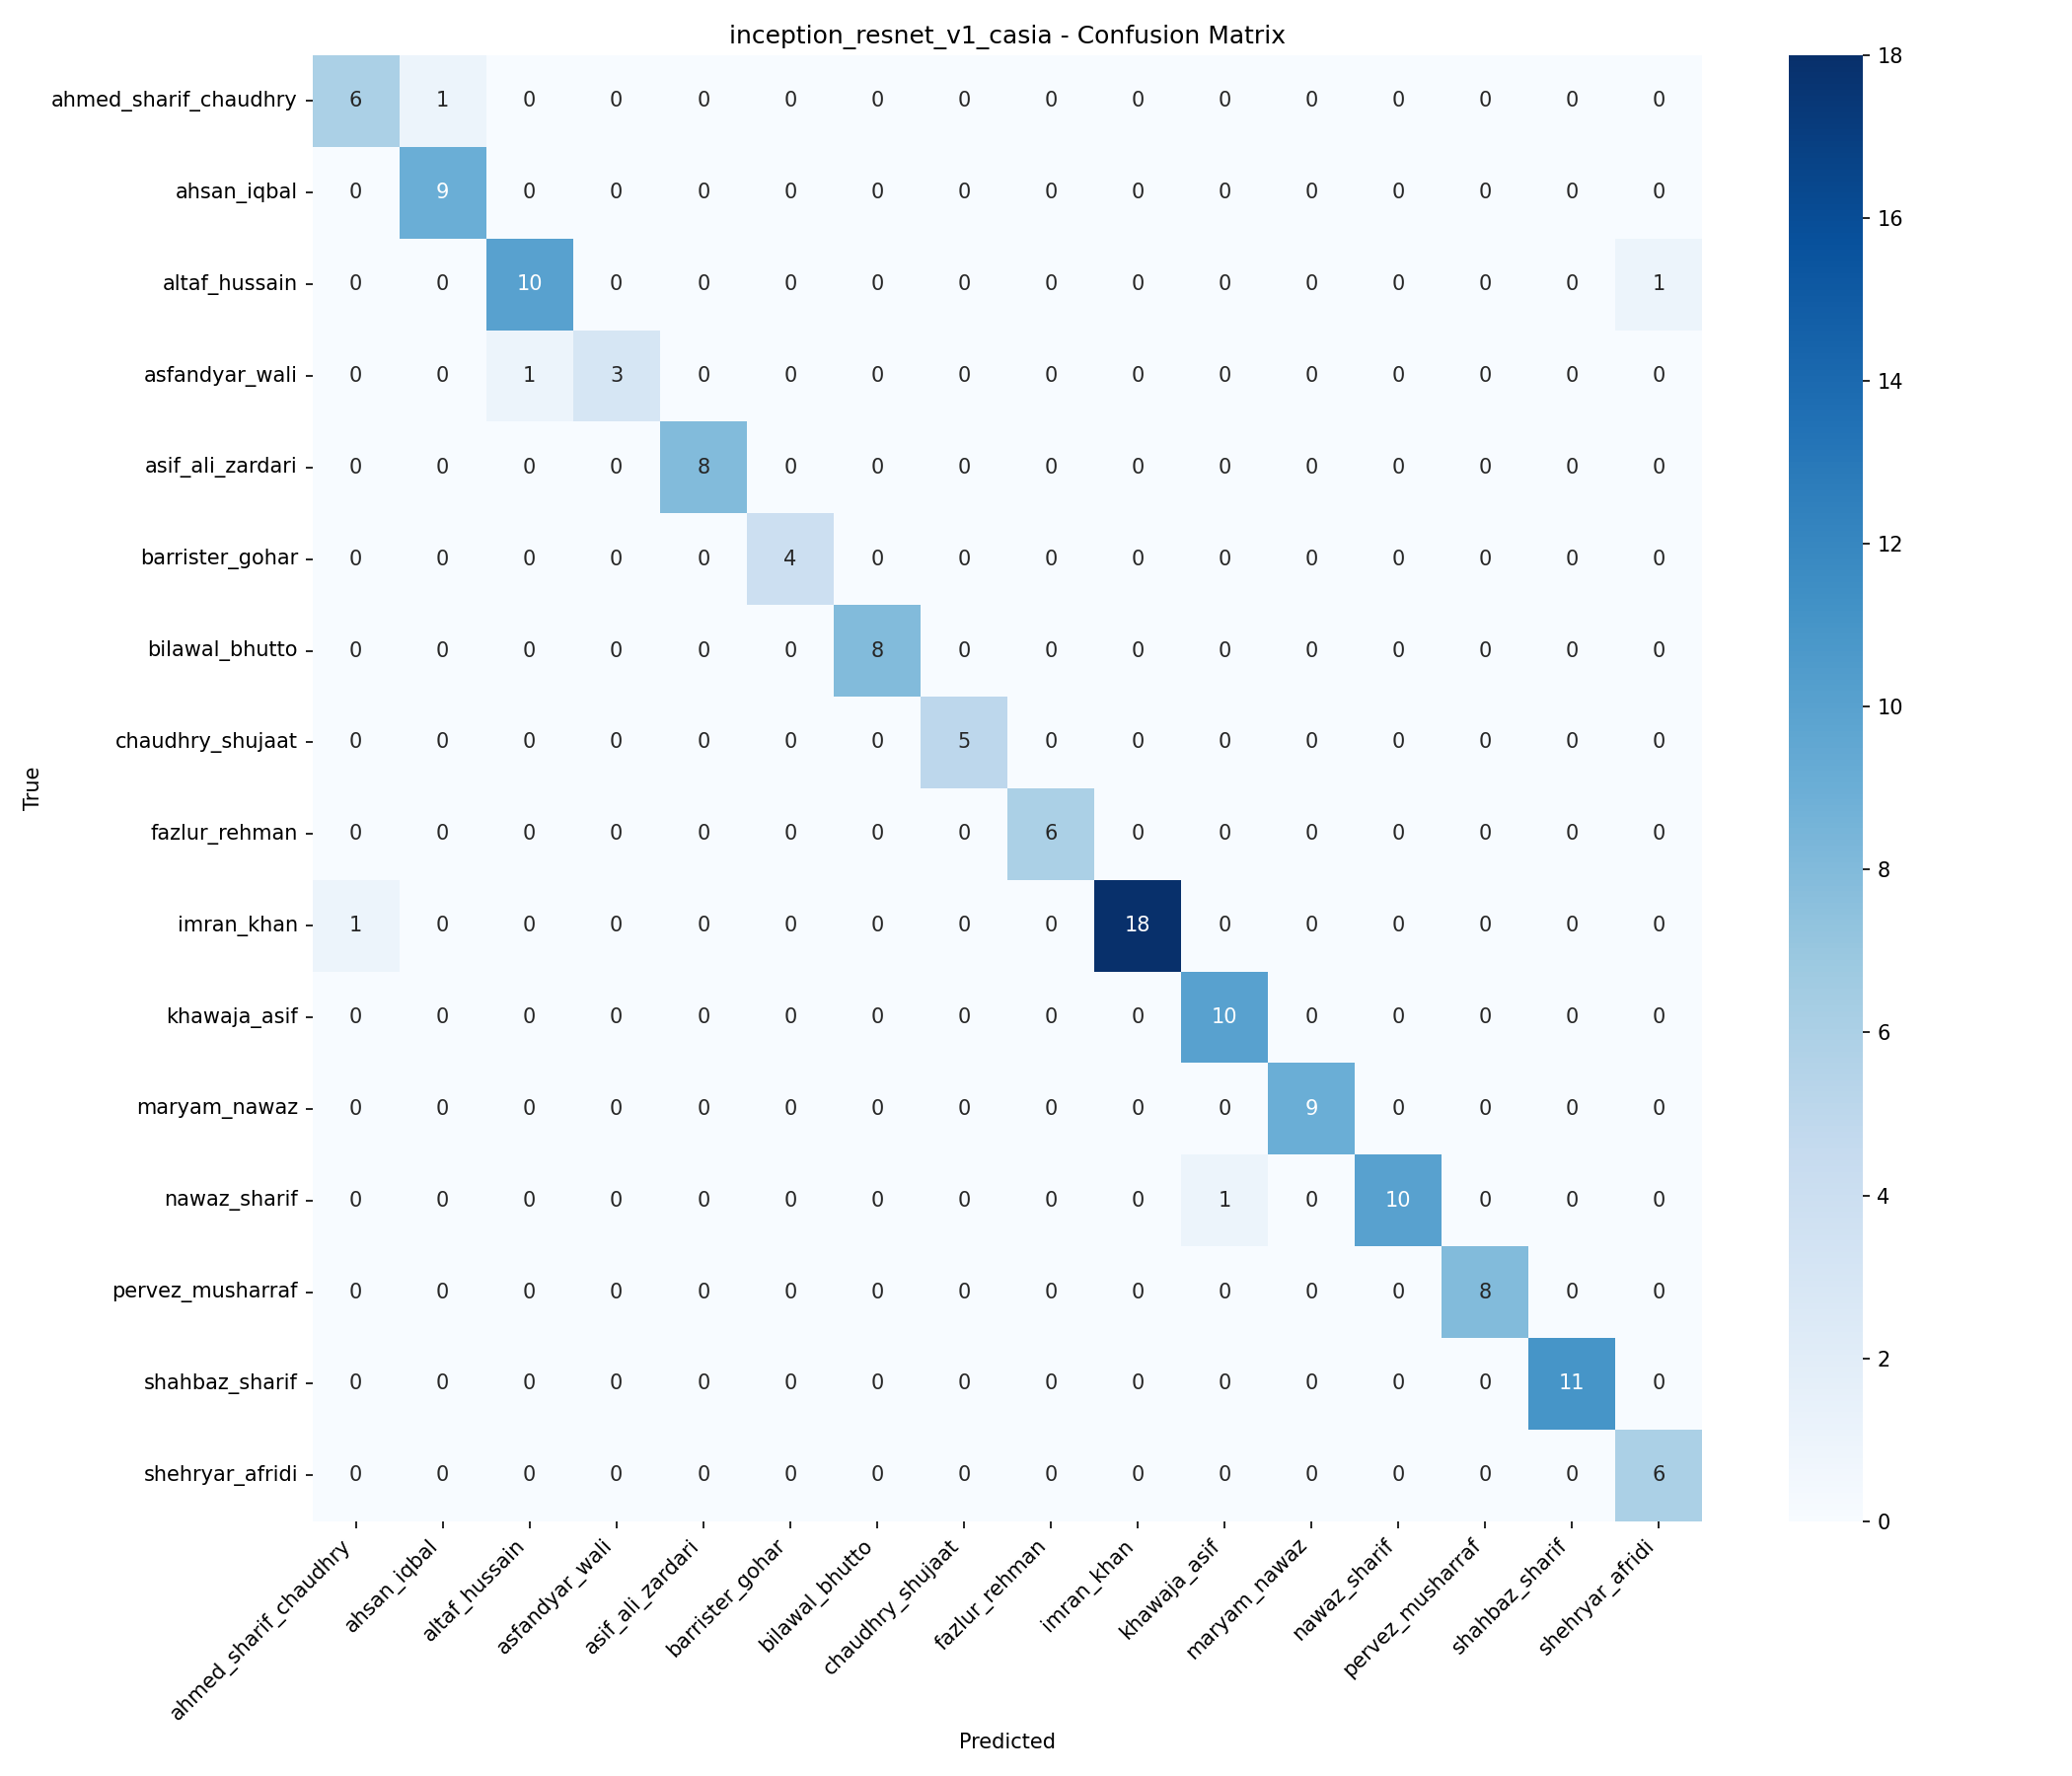

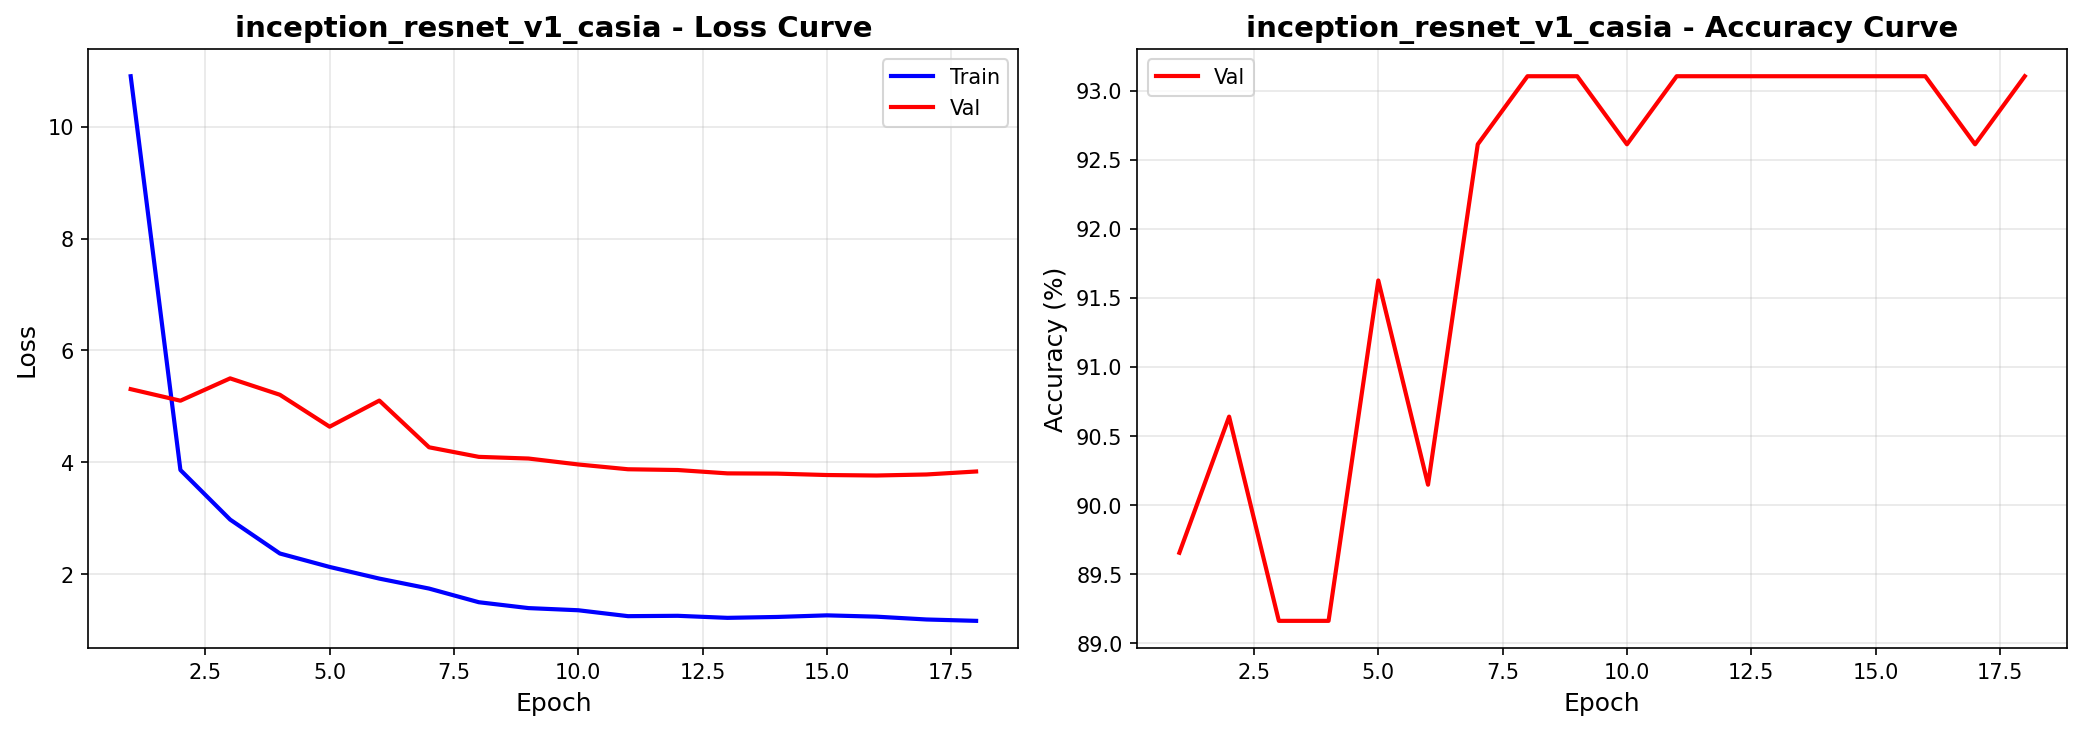

## ResNet-50

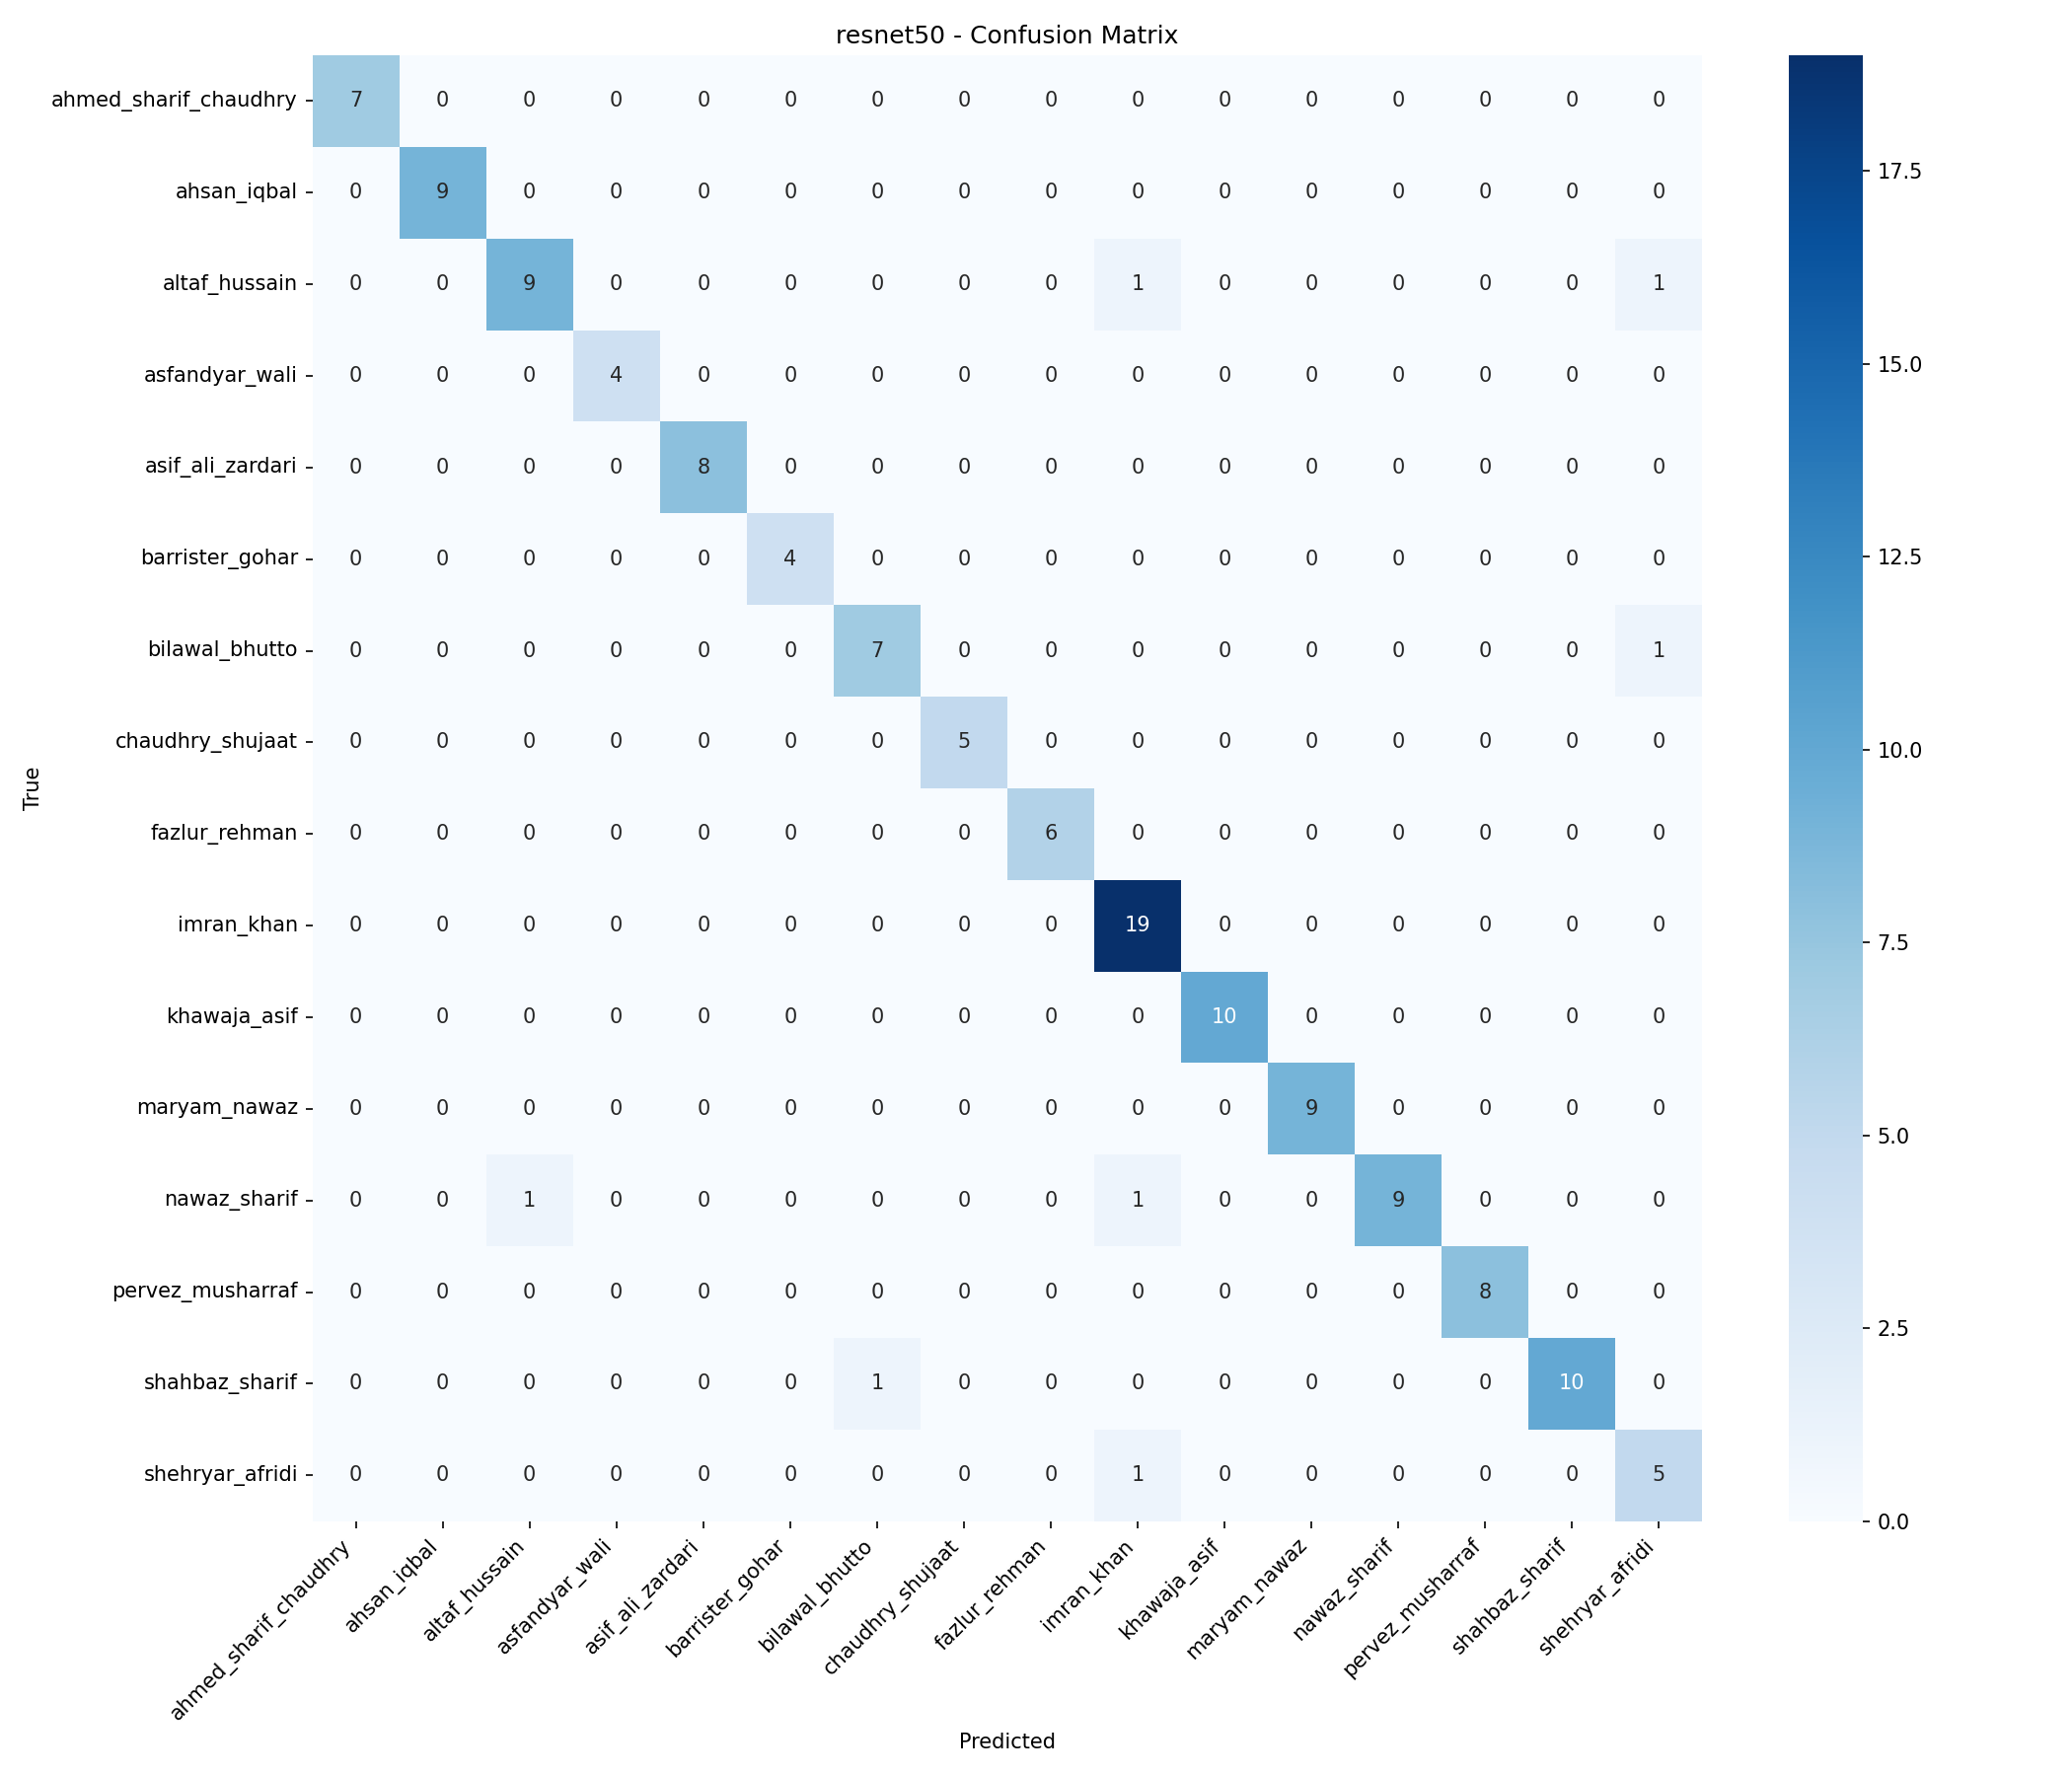

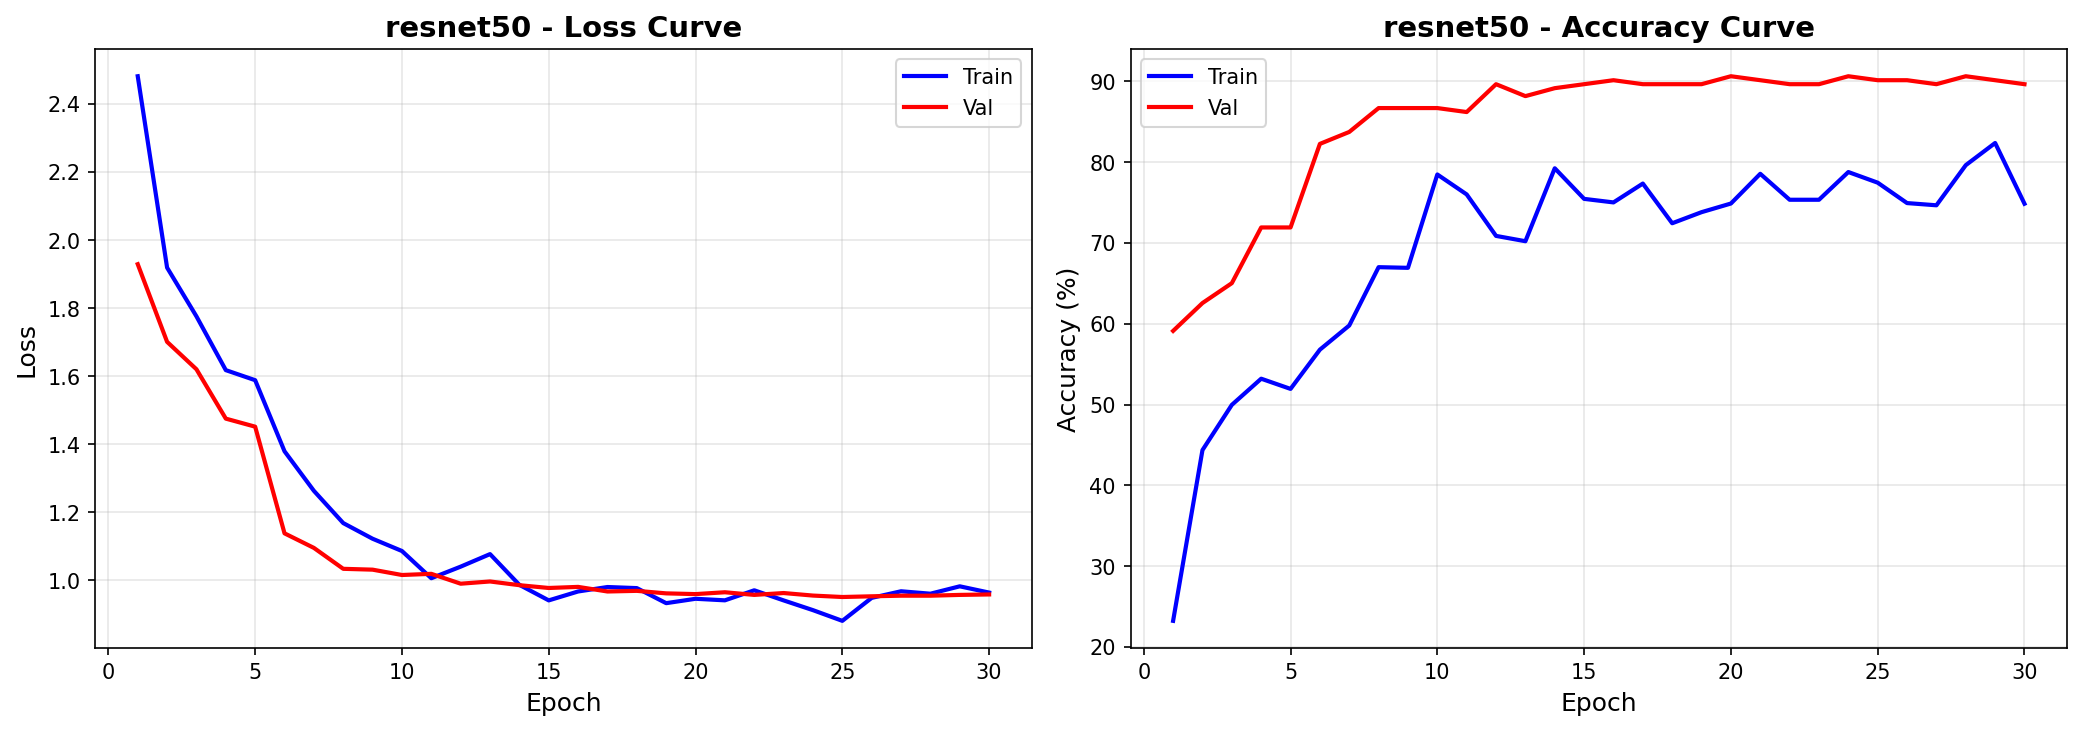

In [4]:
from IPython.display import Image, display, Markdown
import os

plots_dir = "/kaggle/working/plots"
files = sorted([f for f in os.listdir(plots_dir) if f.endswith('.png')])

# Group files by model name (prefix before first underscore or a known pattern)
models = {}
for f in files:
    # Model name is everything before the first '_' after the common prefix? 
    # The files look like: inception_resnet_v1_casia_confusion_matrix.png
    # or inception_resnet_v1_confusion_matrix.png
    # We'll extract the part that matches the model name used in the pipeline.
    if f.startswith('inception_resnet_v1_casia'):
        model = 'InceptionResNetV1 (CASIA)'
    elif f.startswith('inception_resnet_v1'):
        model = 'InceptionResNetV1 (VGGFace2)'
    elif f.startswith('resnet50'):
        model = 'ResNet-50'
    else:
        model = 'Other'
    models.setdefault(model, []).append(f)

# Order we want (same as shown in final results)
model_order = ['InceptionResNetV1 (VGGFace2)', 'InceptionResNetV1 (CASIA)', 'ResNet-50']

for model in model_order:
    if model in models:
        display(Markdown(f"## {model}"))
        # Show confusion matrix first (if exists), then training curves
        # Sort so that confusion matrix comes first (contains 'confusion' in name)
        plots = sorted(models[model], key=lambda x: 'confusion' not in x)
        for fname in plots:
            display(Image(filename=os.path.join(plots_dir, fname)))

In [5]:
!pip install --no-deps facenet-pytorch

  Using cached facenet_pytorch-2.6.0-py3-none-any.whl.metadata (12 kB)
Using cached facenet_pytorch-2.6.0-py3-none-any.whl (1.9 MB)


Config has 16 classes.


--- Loading InceptionResNetV1 (VGGFace2) ---
Logits shape: torch.Size([1, 16]) -> expected 16 classes

--- Loading InceptionResNetV1 (CASIA) ---
Logits shape: torch.Size([1, 16]) -> expected 16 classes

--- Loading ResNet-50 ---
Logits shape: torch.Size([1, 512]) -> expected 16 classes


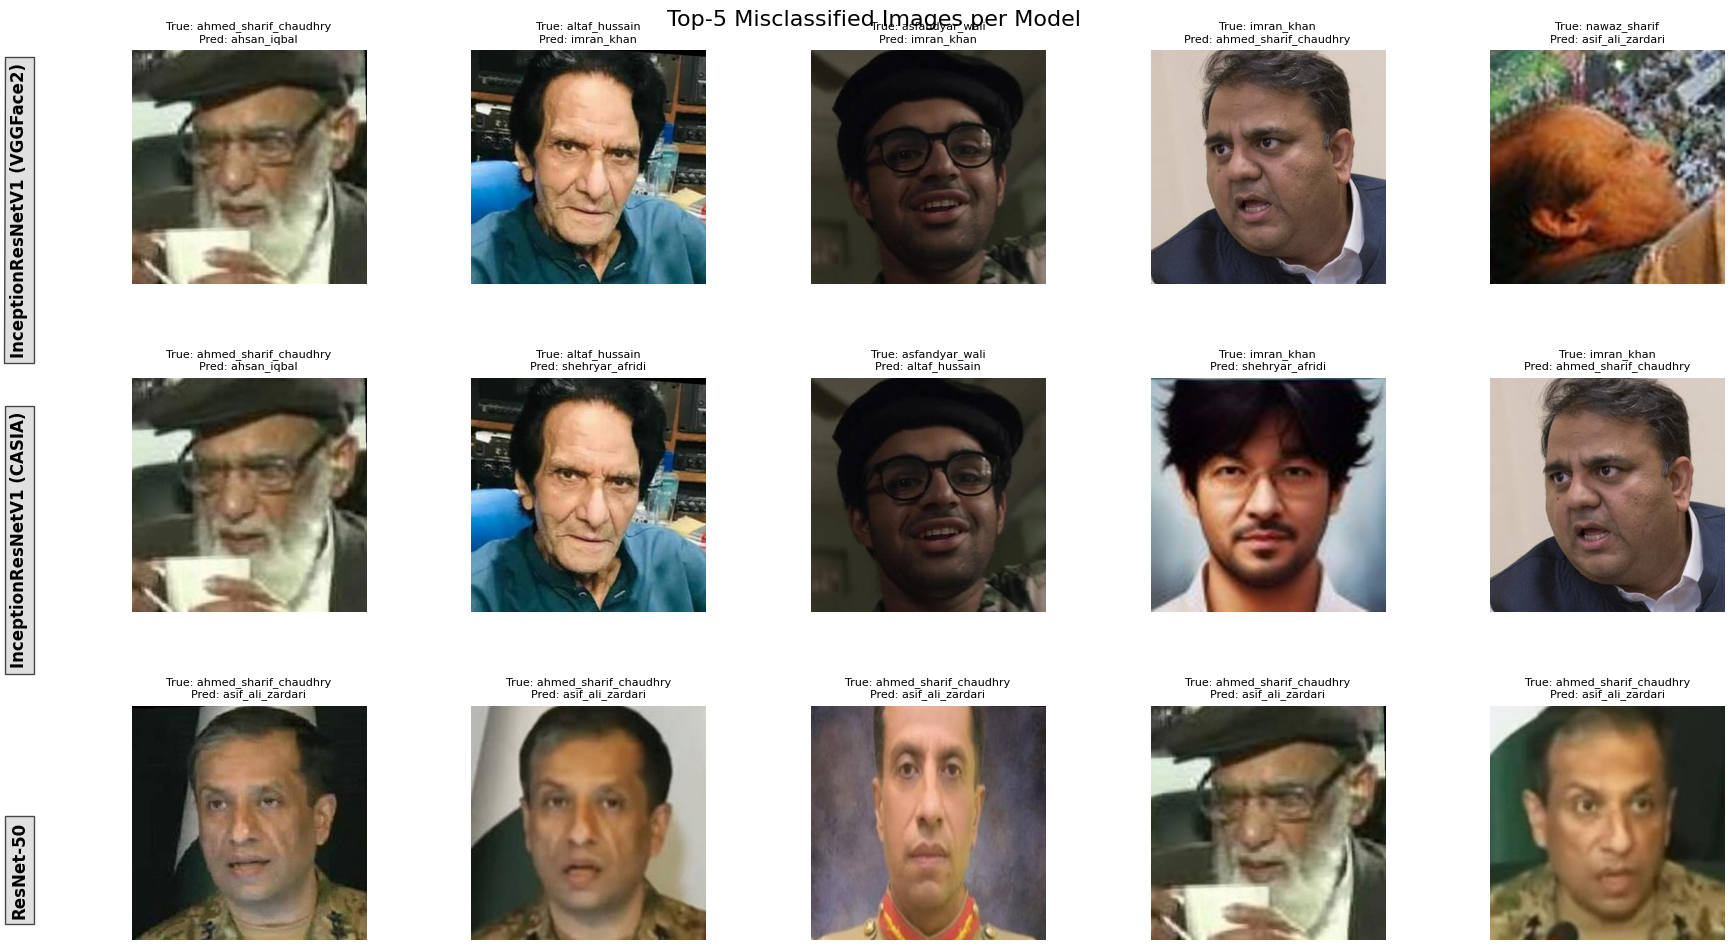

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.models as tv_models
from torchvision import transforms
from facenet_pytorch import InceptionResnetV1
from training.config import config
from training.datasets import PoliticianDataset
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_files = {
    'InceptionResNetV1 (VGGFace2)': 'inception_resnet_v1_best.pth',
    'InceptionResNetV1 (CASIA)':   'inception_resnet_v1_casia_best.pth',
    'ResNet-50':                   'resnet50_best.pth',
}

# ---------- Model loading ----------
def load_checkpoint(model_name, weight_file):
    checkpoint = torch.load(os.path.join('/kaggle/working/models', weight_file),
                           map_location=device)
    state_dict = checkpoint['model_state_dict']
    
    if 'resnet50' in model_name.lower():
        model = tv_models.resnet50(pretrained=False)
        model.fc = torch.nn.Sequential(
            torch.nn.Dropout(0.5),
            torch.nn.Linear(2048, 16)
        )
        model.load_state_dict(state_dict)
        model.eval()
        return model.to(device), None, 'imagenet'
    else:
        stripped_dict = {}
        for k, v in state_dict.items():
            if k.startswith('backbone.'):
                stripped_dict[k[len('backbone.'):]] = v
        backbone = InceptionResnetV1(pretrained=None, classify=False)
        backbone.load_state_dict(stripped_dict, strict=False)
        backbone.eval()
        arcface_eval = checkpoint.get('arcface_eval', None)
        backbone.arcface_eval = arcface_eval
        return backbone.to(device), arcface_eval, 'inception'

def embeddings_to_logits(embeddings, arcface_eval):
    weight = arcface_eval['weight'].to(embeddings.device)
    scale = float(arcface_eval['scale'])
    e = torch.nn.functional.normalize(embeddings, dim=1)
    w = torch.nn.functional.normalize(weight, dim=1)
    return scale * (e @ w.t())

def denorm_inception(img_tensor):
    mean = torch.tensor([0.5, 0.5, 0.5]).view(3,1,1)
    std  = torch.tensor([0.5, 0.5, 0.5]).view(3,1,1)
    img = img_tensor * std + mean
    img = img.permute(1,2,0).cpu().numpy()
    return np.clip(img, 0, 1)

def denorm_imagenet(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img_tensor * std + mean
    img = img.permute(1,2,0).cpu().numpy()
    return np.clip(img, 0, 1)

# ---------- Main plotting ----------
num_classes = len(config.CLASS_NAMES)
print(f"Config has {num_classes} classes.\n")

# Create figure: 3 rows, 5 columns, with extra space on left for row labels
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
fig.suptitle('Top‑5 Misclassified Images per Model', fontsize=16, y=0.98)

for row, (model_name, weight_file) in enumerate(model_files.items()):
    print(f"\n--- Loading {model_name} ---")
    model, arcface_eval, norm_type = load_checkpoint(model_name, weight_file)

    # Transform for test dataset
    normalize = transforms.Normalize(
        mean=[0.5,0.5,0.5] if norm_type == 'inception' else [0.485,0.456,0.406],
        std =[0.5,0.5,0.5] if norm_type == 'inception' else [0.229,0.224,0.225]
    )
    val_transform = transforms.Compose([
        transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),
        transforms.ToTensor(),
        normalize
    ])
    test_dataset = PoliticianDataset(
        os.path.join(config.DATA_DIR, 'test'),
        transform=val_transform
    )
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)

    # Check output shape
    with torch.no_grad():
        dummy = torch.randn(1, 3, config.IMAGE_SIZE, config.IMAGE_SIZE).to(device)
        out = model(dummy)
        if arcface_eval is not None:
            logits = embeddings_to_logits(out, arcface_eval)
        else:
            logits = out
        print(f"Logits shape: {logits.shape} -> expected {num_classes} classes")
        if logits.shape[1] != num_classes:
            print(f"WARNING: Model outputs {logits.shape[1]} classes. Will truncate to first {num_classes} (once).")
            truncate_needed = True
        else:
            truncate_needed = False

    wrongs = []
    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            if arcface_eval is not None:
                logits = embeddings_to_logits(outputs, arcface_eval)
            else:
                logits = outputs
            if truncate_needed:
                logits = logits[:, :num_classes]   # truncate silently after first warning
            _, pred = torch.max(logits, 1)
            if pred.item() != labels.item():
                wrongs.append((images[0].cpu(), labels.item(), pred.item()))
            if len(wrongs) >= 5:
                break

    denorm = denorm_inception if norm_type == 'inception' else denorm_imagenet

    # Display misclassifications in this row
    for col, (img_tensor, true, pred) in enumerate(wrongs):
        ax = axes[row, col]
        img = denorm(img_tensor)
        ax.imshow(img)
        
        # Safe title
        true_name = config.CLASS_NAMES[true] if true < num_classes else f"ID {true}"
        pred_name = config.CLASS_NAMES[pred] if pred < num_classes else f"ID {pred}"
        ax.set_title(f'True: {true_name}\nPred: {pred_name}', fontsize=8)
        ax.axis('off')
    
    # Turn off empty subplots in this row
    for col in range(len(wrongs), 5):
        axes[row, col].axis('off')
    
    # Add model name as a row label on the left (using y-coordinate)
    fig.text(0.02, 0.78 - row*0.33, model_name, va='center', rotation='vertical',
             fontsize=12, weight='bold', backgroundcolor='lightgray', bbox=dict(facecolor='lightgray', alpha=0.7))

plt.subplots_adjust(left=0.08, right=0.98, top=0.94, bottom=0.05, wspace=0.3, hspace=0.4)
plt.show()

---

## Final Notes

This notebook is a **thin wrapper**. The underlying pipeline is a standalone,
fully modular Python package located in `training/`:

```
training/
  config.py      # Central hyperparameters and paths
  arcface.py     # ArcMarginProduct + ArcFaceLoss
  models.py      # Model factories and wrappers
  data_prep.py   # MTCNN alignment, pHash dedup, split, augmentation
  datasets.py    # PoliticianDataset and DataLoader factory
  training.py    # ArcFace and CrossEntropy training loops
  evaluate.py    # Evaluation, confusion matrix, mislabeled audit
  predict.py     # Single-image inference CLI
  main.py        # Orchestration entry point
```

To run outside Kaggle:

```bash
pip install -r requirements.txt
python training/main.py
```

Configuration (epochs, models, ArcFace margin, augmentation threshold, etc.)
is centralised in `training/config.py`.